# Bài tập buổi 6 — Hồi quy tuyến tính

**Sinh viên thực hiện:** "BÙI PHONG HỢP"

---

## Bối cảnh

Trong bài tập này, bạn sẽ làm việc với bộ dữ liệu **California Housing** (Dự đoán giá nhà tại California dựa trên các đặc trưng nhân khẩu học và địa lý). Bài toán đặt ra là bài toán **Hồi quy (Regression)**.

Nhiệm vụ của bạn là xây dựng luồng xử lý dữ liệu và huấn luyện 3 biến thể của Hồi quy tuyến tính:
1. **Vanilla Linear Regression** (Hồi quy tuyến tính thông thường)
2. **Ridge Regression** (Hồi quy với chuẩn hóa L2)
3. **Lasso Regression** (Hồi quy với chuẩn hóa L1)

## Mục tiêu bài tập

1. Thực hiện Load dữ liệu và Khám phá dữ liệu (EDA) cơ bản.
2. Chia tập Train/Test và tiền xử lý (Scaling) đúng chuẩn, không gây Data Leakage.
3. Huấn luyện và đánh giá mô hình bằng các metric chuẩn cho Regression (RMSE, R²).
4. **Trực quan hóa hệ số hồi quy (Coefficients)** để hiểu rõ tính chất thu nhỏ (shrinkage) của Ridge và khả năng chọn lọc đặc trưng (feature selection) của Lasso.

---


## 0. Chuẩn bị môi trường & Import Thư viện

Ô này chứa sẵn các thư viện cần thiết. Nếu bạn cần dùng thêm thư viện nào, hãy bổ sung vào đây.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)  # Cố định random seed
print("Đã import xong thư viện.")

Đã import xong thư viện.


---
## Task 1 — Tải dữ liệu và Khám phá ban đầu (EDA)

### Yêu cầu
1. Tải bộ dữ liệu `California Housing` từ `sklearn.datasets`.
2. Chuyển đổi thành pandas DataFrame. Gán cột target là `MedHouseVal` (Giá nhà trung bình - đơn vị trăm nghìn USD).
3. In ra số dòng, số cột (shape) và thông tin kiểu dữ liệu (`.info()`).
4. Kiểm tra xem có giá trị thiếu (Missing values) nào trong bộ dữ liệu không.

### Gợi ý
- Hàm `fetch_california_housing(as_frame=True)` hỗ trợ trả về DataFrame trực tiếp qua thuộc tính `.frame`.
- Dùng `df.isnull().sum()` để đếm số lượng giá trị thiếu cho mỗi cột.

In [26]:
# TODO 1: Load dữ liệu, tạo DataFrame và kiểm tra tổng quan
# Trả về dữ liệu dưới dạng pandas DataFrame (.data, .target, .frame)
california = fetch_california_housing(as_frame = True)
#(.frame : gộp cả các cột feature và cột target)
df = california.frame

# In shape, info và kiểm tra missing values
print("Kich thuoc du lieu:", df.shape)
print("\nSo phan tu non-null và dtype cua cac cot:", df.info())

count_missing_value = df.isnull().sum()
print("So missing value cua cac cot:\n", count_missing_value)

df.head()

Kich thuoc du lieu: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

So phan tu non-null và dtype cua cac cot: None
So missing value cua cac cot:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---
## Task 2 — Trực quan hóa Phân phối & Tương quan

### Yêu cầu
1. Vẽ biểu đồ Histogram (có đường cong KDE) cho biến mục tiêu `MedHouseVal`. Nhận xét xem phân phối có bị lệch (skew) không.
2. Vẽ ma trận tương quan (Heatmap) giữa tất cả các biến số trong dữ liệu.
3. **Trả lời:** Đặc trưng nào có độ tương quan dương mạnh nhất với giá nhà (`MedHouseVal`)?

### Gợi ý
- Sử dụng `sns.histplot(data=df, x='MedHouseVal', kde=True)` để vẽ phân phối.
- Dùng `df.corr()` để tính ma trận tương quan và đưa vào `sns.heatmap(..., annot=True, cmap='coolwarm', fmt=".2f")` để vẽ biểu đồ nhiệt.

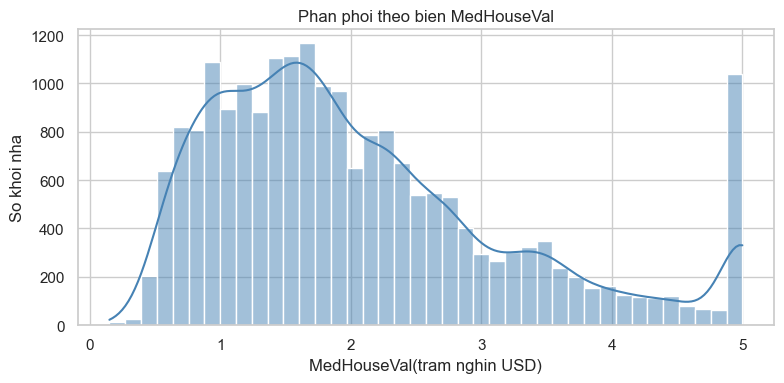

Gia tri skewness cua bien MedHouseVal: 0.98


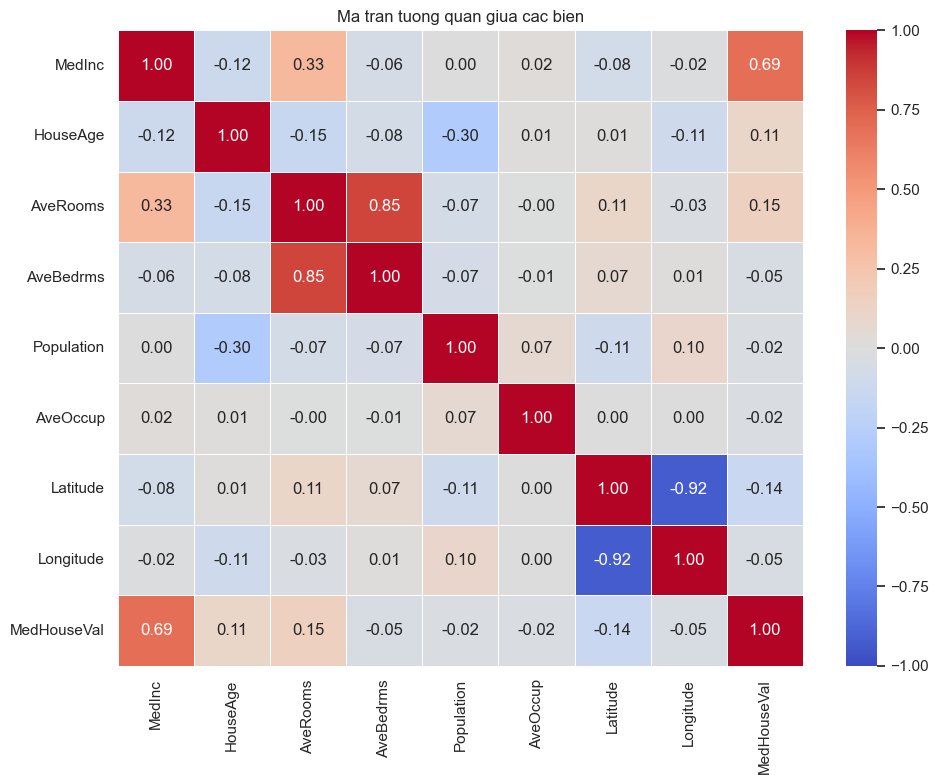


Tuong quan cua cac bien dac trung voi MedHouseVal:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

 Bien co tuong quan lon nhat: 0.69


In [27]:
# TODO 2a: Vẽ Histogram cho biến MedHouseVal
plt.figure(figsize= (8 , 4))
sns.histplot(data = df, x = "MedHouseVal", kde = True, bins = 40, color = "steelblue")
plt.title("Phan phoi theo bien MedHouseVal")
plt.xlabel("MedHouseVal(tram nghin USD)")
plt.ylabel("So khoi nha")
plt.tight_layout()
plt.show()

print("Gia tri skewness cua bien MedHouseVal:" , df["MedHouseVal"].skew().round(2))

# TODO 2b: Vẽ Heatmap correlation cho toàn bộ dữ liệu
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, vmin = -1, vmax = 1, annot = True, fmt = ".2f", cmap = "coolwarm", linewidths = 0.5)
plt.title("Ma tran tuong quan giua cac bien")
plt.tight_layout()
plt.show()

# Tìm biến có tương quan lớn nhất với biến target
sorted_corr = corr_matrix["MedHouseVal"].sort_values(ascending = False)
print("\nTuong quan cua cac bien dac trung voi MedHouseVal:")
print(sorted_corr)
print("\n Bien co tuong quan lon nhat:", sorted_corr.values[1].round(2))

**Trả lời 2:**
1. Phân phối của **MedHouseVal** bị **lệch phải** (skewness = 0.98 > 0): phần lớn giá nhà tập trung ở khoảng 1 – 2(trăm nghìn USD), và có một đuôi dài kéo về phía giá nhà cao. Ngoài ra xuất hiện một cột rất cao tại đúng giá trị 5(trăm nghìn USD): đây là do bộ dữ liệu bị giới hạn trần tại 500.000 USD, nên không phải là nhiễu.
2. Đặc trưng có tương quan dương mạnh nhất với **MedHouseVal** là **MedInc** (thu nhập trung bình của mỗi hộ gia đình trong khối nhà), với hệ số tương quan khoảng **0.69**. Hiểu rằng: khu vực có thu nhập dân cư cao thường có giá nhà cao hơn.

---
## Task 3 — Chia tập dữ liệu và Tiền xử lý (Scaling)

Với các mô hình có sử dụng Regularization như Ridge và Lasso, việc **Scale dữ liệu** (đưa về cùng thang đo) là **BẮT BUỘC**. Nếu không scale, các đặc trưng có miền giá trị lớn (ví dụ như Population) sẽ lấn át các đặc trưng có miền giá trị nhỏ, làm sai lệch tác dụng của hệ số phạt L1/L2.

### Yêu cầu
1. Tách features (`X`) và target (`y`).
2. Chia tập Train/Test theo tỷ lệ **80/20**.
3. Dùng `StandardScaler` để scale tập `X`. **Quan trọng:** Chỉ `.fit()` trên `X_train`, sau đó dùng tham số đã học đó để `.transform()` cho cả `X_train` và `X_test`.

### Gợi ý
- `train_test_split(X, y, test_size=0.2, random_state=42)`.
- `scaler.fit_transform(X_train)` cho tập train và `scaler.transform(X_test)` cho tập test.

In [28]:
# TODO 3: Chia tập và Scale dữ liệu
X = df.drop(columns = "MedHouseVal")
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print("Kich thuoc X_train:", X_train.shape)           # (16512, 8)
print("Kich thuoc X_test:", X_test.shape)             # (4128, 8)

scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train)    # Chỉ fit trên tập train
X_test_scaled = scaler.transform(X_test)

print(list(scaler.get_feature_names_out()))

Kich thuoc X_train: (16512, 8)
Kich thuoc X_test: (4128, 8)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


---
## Task 4 — Huấn luyện Vanilla Linear Regression

### Yêu cầu
1. Khởi tạo và huấn luyện mô hình `LinearRegression` trên tập Train đã scale.
2. Dự đoán trên tập Test.
3. Tính và in ra 2 chỉ số đánh giá: **RMSE** (Root Mean Squared Error) và **R² Score**.

### Gợi ý
- RMSE có thể tính bằng `np.sqrt(mean_squared_error(y_true, y_pred))`.
- Hàm `r2_score(y_true, y_pred)` sẽ trả về chỉ số R² (hệ số xác định).

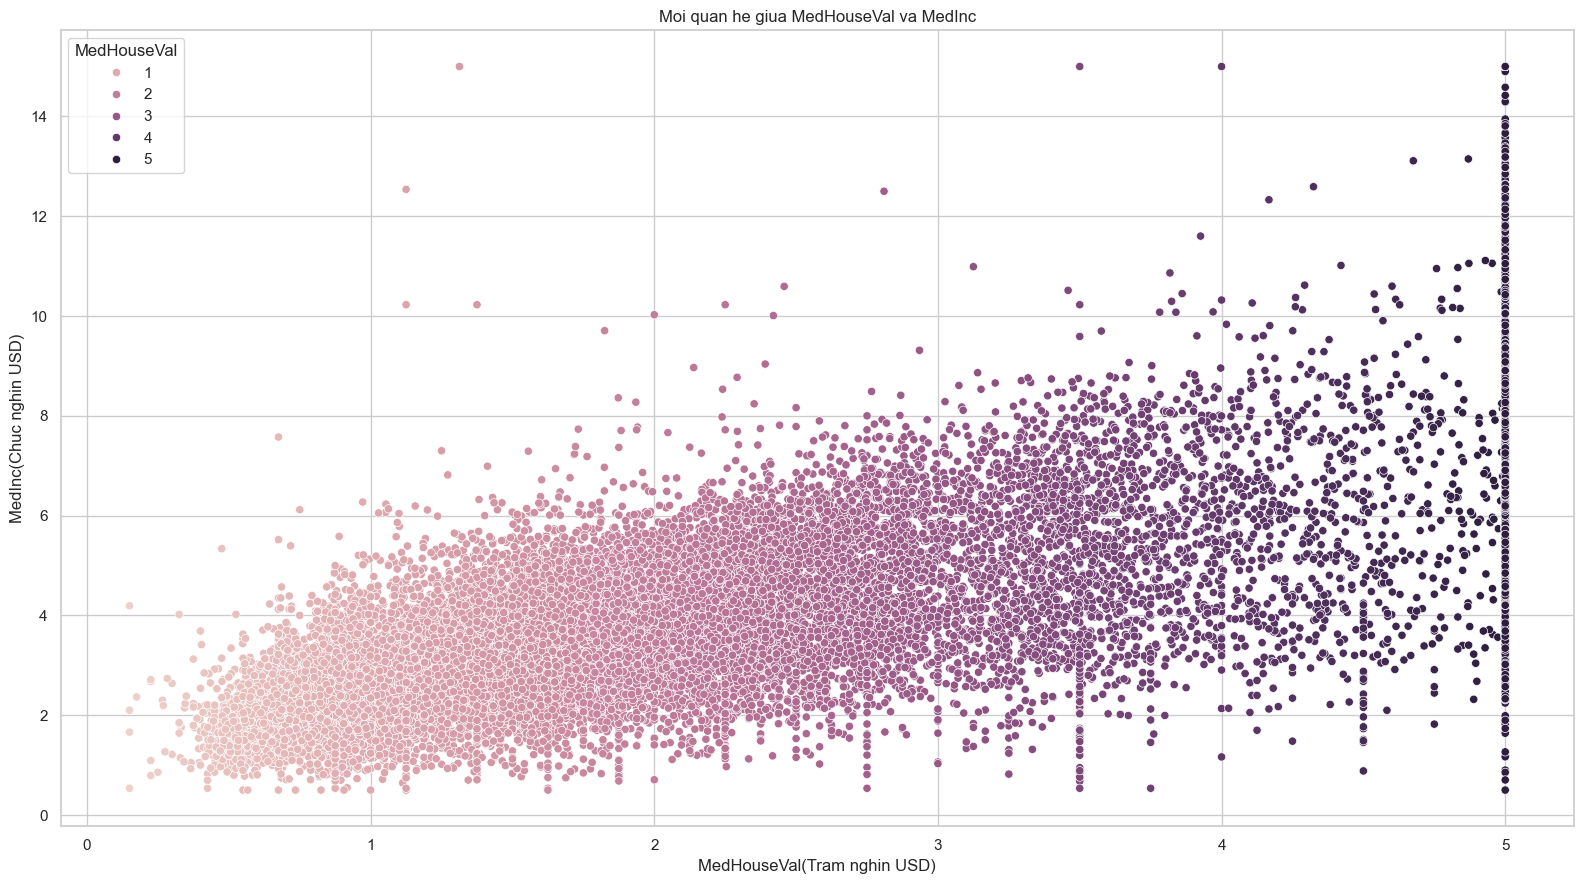

In [29]:
# Vẽ mối quan hệ tuyến tính giữa MedHouseVal và MedInc
plt.figure(figsize = (16 , 9))
sns.scatterplot(data = df, x = "MedHouseVal", y = "MedInc", hue = "MedHouseVal")
plt.title("Moi quan he giua MedHouseVal va MedInc")
plt.xlabel("MedHouseVal(Tram nghin USD)")
plt.ylabel("MedInc(Chuc nghin USD)")
plt.tight_layout()
plt.show()

In [30]:
# TODO 4: Huấn luyện và Đánh giá Linear Regression
lr_model = LinearRegression()

# model học trên tập train 
lr_model.fit(X_train_scaled, y_train)

# model dự đoán trên tập test
y_pred_lr = lr_model.predict(X_test_scaled)

# tính căn bậc 2 của trung bình bình phương sai số
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# tính chỉ số R2
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - RMSE: {rmse_lr:.4f}, R2: {r2_lr:.4f}")

Linear Regression - RMSE: 0.7456, R2: 0.5758


---
## Task 5 — Huấn luyện Ridge và Lasso Regression

### Yêu cầu
1. Huấn luyện mô hình **Ridge** với tham số siêu việt `alpha=10.0`.
2. Huấn luyện mô hình **Lasso** với tham số siêu việt `alpha=0.1`.
3. Tính RMSE và R² cho cả 2 mô hình trên tập Test và in kết quả để so sánh.

### Gợi ý
- Khởi tạo mô hình: `Ridge(alpha=10.0)` và `Lasso(alpha=0.1)`.
- Bạn có thể viết một hàm `evaluate_model(model, X_test, y_test)` nhỏ để tái sử dụng code tính RMSE và R² cho đỡ lặp lại.

In [31]:
# Hàm tính RMSE và R2
def evaluate_model(model, X_test, y_test, model_name=""):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name} - RMSE: {rmse:.2f}, R2: {r2:.2f}")
    return rmse, r2, y_pred

# TODO 5a: Huấn luyện và Đánh giá Ridge Regression
ridge_model = Ridge(alpha = 10.0)
ridge_model.fit(X_train_scaled, y_train)
rmse_ridge, r2_ridge, y_pred_ridge = evaluate_model(ridge_model, X_test_scaled, y_test, model_name = "Ridge Regression")

# TODO 5b: Huấn luyện và Đánh giá Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)
rmse_lasso, r2_lasso, y_pred_lasso = evaluate_model(lasso_model, X_test_scaled, y_test, model_name = "Lasso Regression")

Ridge Regression - RMSE: 0.75, R2: 0.58
Lasso Regression - RMSE: 0.82, R2: 0.48


---
## Task 6 — Trực quan hóa Hệ số hồi quy (Coefficients)

Đây là phần cốt lõi để thấy sự khác biệt về mặt toán học giữa L1 và L2 Regularization.

### Yêu cầu
1. Lấy mảng hệ số hồi quy (`.coef_`) từ cả 3 mô hình (Linear, Ridge, Lasso).
2. Tạo một DataFrame lưu trữ các hệ số này với Index là tên các features.
3. Vẽ biểu đồ Barplot so sánh các trọng số của 3 mô hình cạnh nhau cho từng feature.
4. **Trả lời:** Quan sát hệ số của Lasso, bạn thấy điều gì đặc biệt xảy ra với một số features? Tính chất này thường được ứng dụng để làm gì?

### Gợi ý
- `california.feature_names` trả về danh sách tên cột.
- Có thể gom thành Pandas DataFrame và gọi lệnh `df_coefs.plot(kind='bar', figsize=(12, 6))` để pandas tự động vẽ các thanh cạnh nhau.

In [32]:
# So sánh 3 mô hình:
compare_df = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "RMSE": [rmse_lr, rmse_ridge, rmse_lasso],
    "R2_SCORE": [r2_lr, r2_ridge, r2_lasso]
})
display(compare_df)

,Model,RMSE,R2_SCORE
0,Linear,0.745581,0.575788
1,Ridge,0.745342,0.576060
2,Lasso,0.824396,0.481361


Bang he so hoi quy cua 3 mo hinh:
              Linear     Ridge     Lasso
MedInc      0.854383  0.853814  0.710598
HouseAge    0.122546  0.123316  0.106453
AveRooms   -0.294410 -0.292412 -0.000000
AveBedrms   0.339259  0.336750  0.000000
Population -0.002308 -0.002055 -0.000000
AveOccup   -0.040829 -0.040867 -0.000000
Latitude   -0.896929 -0.889384 -0.011469
Longitude  -0.869842 -0.862199 -0.000000


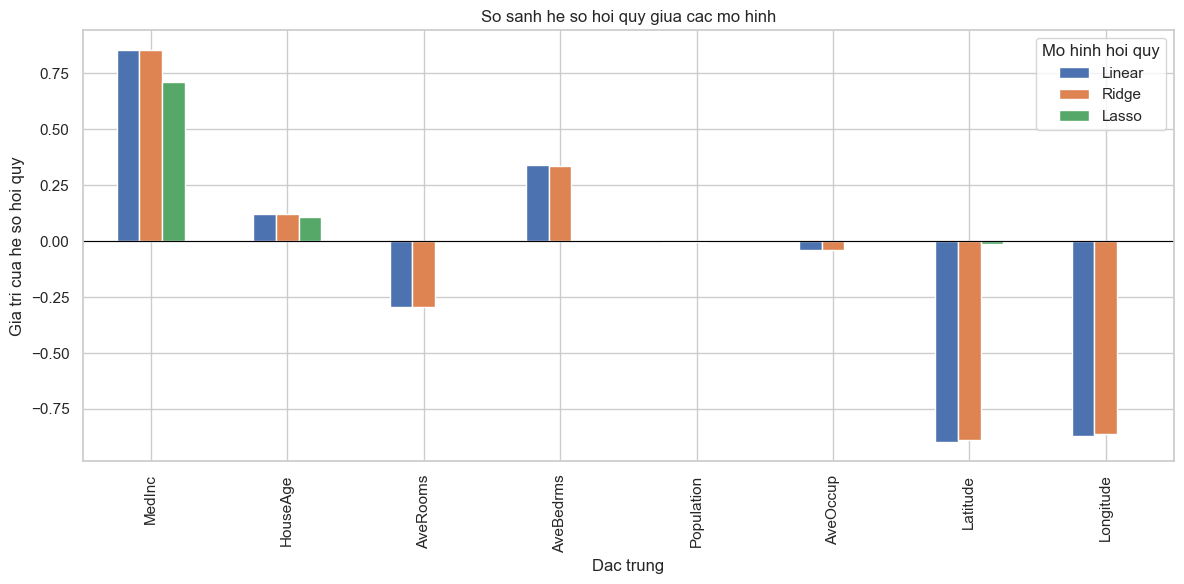

In [33]:
# TODO 6: Trực quan hóa Coefficients
# Lấy danh sách tên các cột của X (các biến feature)
features = X.columns

#
coef_df = pd.DataFrame({
     'Linear': lr_model.coef_,
     'Ridge': ridge_model.coef_,
     'Lasso': lasso_model.coef_
}, index = features)

print("Bang he so hoi quy cua 3 mo hinh:")
print(coef_df)

# Vẽ biểu đồ so sánh
coef_df.plot(kind = "bar", figsize=(12 , 6))
plt.title("So sanh he so hoi quy giua cac mo hinh")
plt.ylabel("Gia tri cua he so hoi quy")
plt.xlabel("Dac trung")
plt.axhline(0, color = "black", linewidth = 0.8)  # đường mốc y = 0 để dễ dàng quan sát dấu của hệ số hồi quy
plt.legend(title = "Mo hinh hoi quy")
plt.tight_layout()
plt.show()

**Trả lời 6:**
- Với **Ridge**, các hệ số của **Ridge** nhỏ hơn một chút so với **Linear Regression**, nhưng hầu như **không có hệ số nào bằng đúng 0**.
- Với **Lasso**, một số hệ số của các feature: **AveRooms**, **AveBedrms**, **AveOccup**, **Population**, hoặc các đặc trưng vĩ độ/kinh độ bị ép về **đúng bằng 0**.
    + Tính chất đưa hệ số hồi quy về đúng bằng 0 của **Lasso** được ứng dụng để làm **chọn lọc đặc trưng tự động**: mô hình tự loại bỏ những đặc trưng ít quan trọng, dư thừa, hay tương quan quá mạnh với nhau(đa cộng tuyến) khỏi công thức dự đoán, giúp mô hình giảm nguy cơ overfitting.

---
## (Bonus) Task 7 — Tìm siêu tham số tối ưu với GridSearchCV

Ở Task 5, chúng ta chỉ chọn bừa `alpha=10.0` và `alpha=0.1`. Làm sao để biết `alpha` bao nhiêu là tốt nhất cho bộ dữ liệu này?

### Yêu cầu
Sử dụng `GridSearchCV` để chạy thử nghiệm nghiệm chéo (Cross-Validation) tìm giá trị `alpha` tối ưu cho Ridge Regression trong danh sách: `[0.1, 1.0, 10.0, 100.0]`.

### Gợi ý
- Import: `from sklearn.model_selection import GridSearchCV`.
- Cấu hình param grid: `param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}`.
- In ra `grid_search.best_params_` sau khi fit trên tập Train.

In [37]:
# TODO Bonus: GridSearchCV cho Ridge
from sklearn.model_selection import GridSearchCV

# Cấu hình param grid
param_grid = {"alpha": [0.1, 1.0, 10.0, 100.0]}

# GridSearchCV sẽ thực hiện Cross-Validation
# với từng giá trị alpha, rồi chọn ra alpha cho kết quả tốt nhất theo scoring đã chọn.
# scoring='neg_root_mean_squared_error': sklearn quy ước "càng lớn càng tốt" cho scoring,
# nên RMSE (càng nhỏ càng tốt) được lấy dấu âm để phù hợp quy ước này.
grid_search = GridSearchCV(
    Ridge(),
    param_grid,
    cv = 5,
    scoring = 'neg_root_mean_squared_error'
)

# Chỉ fit trên tập train (đã scale) để tránh Data Leakage sang tập test
grid_search.fit(X_train_scaled, y_train)

print(f"alpha tot nhat cho Ridge: {grid_search.best_params_}")
print(f"RMSE tot nhat (CV): {-grid_search.best_score_:.2f}")

# Đánh giá lại mô hình tốt nhất trên tập test
best_ridge = grid_search.best_estimator_
_ = evaluate_model(best_ridge, X_test_scaled, y_test, model_name = f"Ridge toi uu(alpha = {grid_search.best_params_["alpha"]})")


alpha tot nhat cho Ridge: {'alpha': 0.1}
RMSE tot nhat (CV): 0.72
Ridge toi uu(alpha = 0.1) - RMSE: 0.75, R2: 0.58


---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không bị lỗi NameError hay SyntaxError.
- [ ] Đã hoàn thiện bước Scale dữ liệu cẩn thận, không có Data Leakage.
- [ ] Đã trực quan hóa đủ các biểu đồ ở Task 2 và Task 6.
- [ ] Đã trả lời phần nhận xét bằng Text ở các câu hỏi (Task 2, Task 6).
